![banner](./images/banner.png)

### Monitoring fires in Congo Basin Peatlands with FIRMS

With this code you can:

1. download MODIS, NOAA and SNPP fire detections from NASA FIRMS for an area of interest and view them by confidence
2. merge them and add attributes to determine if the fire is in a forest concession, protected area, peatland
3. view the data and preliminary analysis
4. export and upload to Google drive for further analysis and visualisation
5. export fires in peatland classes to geoJSON for validation in Open Foris Ground

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import requests
from IPython.display import display, HTML
import geopandas as gpd
from matplotlib import pyplot as plt
from matplotlib import font_manager
import geopandas as gpd
from shapely.geometry import box
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from shapely.geometry import Point
import geemap.foliumap as geemap
import folium
from folium.plugins import HeatMap
from folium import plugins
import ee
from datetime import datetime
from datetime import datetime, date
from datetime import datetime, timedelta
import time
import gspread
import warnings
from io import StringIO
import json
from tqdm import tqdm
import shapely.geometry
from rasterio.sample import sample_gen
from pathlib import Path
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
from google.oauth2.credentials import Credentials

you need to register and download your own key from https://firms.modaps.eosdis.nasa.gov/api/map_key/ don't use mine!

In [2]:
MAP_KEY = "1ccacc221fd0778472a2ea1e55f3e4ae"

In [3]:
# query data_availability to find out what date range is available for various datasets
# this url will return information about all supported sensors and their corresponding datasets
# instead of 'all' you can specify individual sensor, ex:LANDSAT_NRT
da_url = 'https://firms.modaps.eosdis.nasa.gov/api/data_availability/csv/' + MAP_KEY + '/all'
firms_data = pd.read_csv(da_url)
display(firms_data)

,data_id,min_date,max_date
0,MODIS_NRT,2026-01-01,2026-03-04
1,MODIS_SP,2000-11-01,2025-12-31
2,VIIRS_NOAA20_NRT,2026-01-01,2026-03-04
3,VIIRS_NOAA20_SP,2018-04-01,2025-12-31
4,VIIRS_NOAA21_NRT,2024-01-17,2026-03-04
5,VIIRS_SNPP_NRT,2026-01-01,2026-03-04
6,VIIRS_SNPP_SP,2012-01-20,2025-12-31
7,LANDSAT_NRT,2022-06-20,2026-03-04
8,GOES_NRT,2022-08-09,2026-03-04
9,BA_MODIS,2000-11-01,2025-12-01


In [4]:
aoi = gpd.read_file("/home/sepal-user/Peatlands_Congo/gis_data/Peatlands_AOI.shp")

In [5]:
# zones and areas to assess
adm1_path = "/home/sepal-user/Peatlands_Congo/gis_data/peatlands_adm1_aoi.shp"
#adm1_path = "/home/sepal-user/Peatlands_Congo/gis_data/COG_GAUL_2024.shp" # for all of Congo
pas_path = "/home/sepal-user/Peatlands_Congo/gis_data/peatlands_PAs.shp"
conc_cod_path = "/home/sepal-user/Peatlands_Congo/gis_data/forest_concessions_COD.shp"
conc_cog_path = "/home/sepal-user/Peatlands_Congo/gis_data/forest_concessions_COG.shp"

In [6]:
# Get the bounding box of the AOI(minx, miny, maxx, maxy)
minx, miny, maxx, maxy = aoi.total_bounds
bbox = f"{minx},{miny},{maxx},{maxy}"
print(bbox)

14.99932372421427,-5.0016134989061865,25.728357392028784,3.30645703301439


In [7]:
# date from which to start fire observations
start_date = "2026-01-01"

In [8]:
# Generate today's date in YYYY-DD-MM format
today = datetime.now().strftime("%Y-%d-%m")
END_DATE = date.today()
print(today)

2026-04-03


In [9]:
# OR if you want a different end date than today
end_date = "2026-03-01"
print(end_date)

2026-03-01


#### 1. get fire data

In [10]:
SOURCE = "VIIRS_SNPP_NRT"
CHUNK = 5  # FIRMS API limit

all_SNPP_dfs = []

END_DATE = datetime.strptime(end_date, "%Y-%m-%d")
STOP_DATE = datetime.strptime(start_date, "%Y-%m-%d")

current_end = END_DATE

# Expected VIIRS columns
viirs_cols = [
    "latitude","longitude","bright_ti4","scan","track",
    "acq_date","acq_time","satellite","instrument",
    "confidence","version","bright_ti5","frp","daynight"
]

# --------------------------------------------------------------------
# LOOP BACKWARD IN 5-DAY PERIODS
# --------------------------------------------------------------------
while current_end > STOP_DATE:

    end_str = current_end.strftime("%Y-%m-%d")

    url = (
        f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
        f"{MAP_KEY}/{SOURCE}/{bbox}/{CHUNK}/{end_str}"
    )

    print(f"🔹 Requesting {CHUNK} days ending {end_str}")

    try:
        r = requests.get(url, timeout=60)

        if r.status_code == 200 and r.text.strip():

            df = pd.read_csv(StringIO(r.text))

            if not df.empty:

                if "confidence" in df.columns:

                    if df["confidence"].dtype == object:
                        df = df[
                            ~df["confidence"]
                            .astype(str)
                            .str.lower()
                            .isin(["l", "low"])
                        ]
                    else:
                        df = df[df["confidence"] >= 30]

                if not df.empty:
                    print(f"✅ Retrieved {len(df)} records")
                    all_SNPP_dfs.append(df)
                else:
                    print("⚠️ Only low-confidence detections, skipped.")

            else:
                print("⚠️ No data for this interval.")

        else:
            print(f"⚠️ HTTP {r.status_code} — skipping.")

    except Exception as e:
        print(f"⚠️ Request failed: {e}")

    current_end -= timedelta(days=CHUNK)
    time.sleep(2)

# --------------------------------------------------------------------
# Combine results
# --------------------------------------------------------------------
if all_SNPP_dfs:

    all_SNPP = (
        pd.concat(all_SNPP_dfs, ignore_index=True)
        .drop_duplicates()
    )

    all_SNPP["satellite"] = "SNPP"

    print(f"\n🔥 Total combined records: {len(all_SNPP)}")

else:

    # Create empty dataframe with VIIRS schema
    all_SNPP = pd.DataFrame(columns=viirs_cols)
    all_SNPP["satellite"] = []

    print("\n⚠️ No SNPP detections retrieved")

🔹 Requesting 5 days ending 2026-03-01
✅ Retrieved 2790 records
🔹 Requesting 5 days ending 2026-02-24
✅ Retrieved 17970 records
🔹 Requesting 5 days ending 2026-02-19
✅ Retrieved 3456 records
🔹 Requesting 5 days ending 2026-02-14
✅ Retrieved 6552 records
🔹 Requesting 5 days ending 2026-02-09
✅ Retrieved 5057 records
🔹 Requesting 5 days ending 2026-02-04
✅ Retrieved 3999 records
🔹 Requesting 5 days ending 2026-01-30
✅ Retrieved 3149 records
🔹 Requesting 5 days ending 2026-01-25
✅ Retrieved 2714 records
🔹 Requesting 5 days ending 2026-01-20
✅ Retrieved 1272 records
🔹 Requesting 5 days ending 2026-01-15
✅ Retrieved 1238 records
🔹 Requesting 5 days ending 2026-01-10
✅ Retrieved 414 records
🔹 Requesting 5 days ending 2026-01-05
✅ Retrieved 1292 records

🔥 Total combined records: 49903


In [11]:
all_SNPP.head()

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,-0.29940,17.46817,307.66,0.33,0.56,2026-03-01,54,SNPP,VIIRS,n,2.0NRT,285.99,0.76,N
1,1.39788,16.32751,301.87,0.52,0.50,2026-03-01,54,SNPP,VIIRS,n,2.0NRT,281.77,0.89,N
2,1.43145,16.17461,304.67,0.51,0.49,2026-03-01,54,SNPP,VIIRS,n,2.0NRT,280.63,1.03,N
3,2.42297,21.72425,310.28,0.59,0.70,2026-03-01,54,SNPP,VIIRS,n,2.0NRT,283.37,2.97,N
4,2.42366,21.72404,311.06,0.59,0.70,2026-03-01,54,SNPP,VIIRS,n,2.0NRT,283.60,2.95,N


In [12]:
SOURCE = "MODIS_NRT"

DAY_RANGE = 5
STOP_DATE = datetime.strptime(start_date, "%Y-%m-%d")

all_MODIS_dfs = []

# Expected MODIS FIRMS columns
modis_cols = [
    "latitude","longitude","brightness","scan","track",
    "acq_date","acq_time","satellite","instrument",
    "confidence","version","bright_t31","frp","daynight"
]

# --------------------------------------------------------------------
# LOOP BACKWARD IN 5-DAY PERIODS
# --------------------------------------------------------------------
current_end = END_DATE

while current_end > STOP_DATE:

    end_str = current_end.strftime("%Y-%m-%d")

    url = (
        f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
        f"{MAP_KEY}/{SOURCE}/{bbox}/{DAY_RANGE}/{end_str}"
    )

    print(f"🔹 Requesting {DAY_RANGE} days ending {end_str}")

    try:
        r = requests.get(url, timeout=60)

        if r.status_code == 200 and r.text.strip():

            df = pd.read_csv(StringIO(r.text))

            if not df.empty:

                # MODIS confidence is numeric (0–100)
                if "confidence" in df.columns:
                    df = df[df["confidence"] >= 30]

                if not df.empty:
                    print(f"✅ Retrieved {len(df)} records")
                    all_MODIS_dfs.append(df)
                else:
                    print("⚠️ Only low-confidence detections, skipped.")

            else:
                print("⚠️ No data for this interval.")

        else:
            print(f"⚠️ HTTP {r.status_code} — skipping.")

    except Exception as e:
        print(f"❌ Error: {e}")

    current_end -= timedelta(days=DAY_RANGE)
    time.sleep(2)

# --------------------------------------------------------------------
# Combine results
# --------------------------------------------------------------------
if all_MODIS_dfs:

    all_MODIS = (
        pd.concat(all_MODIS_dfs, ignore_index=True)
        .drop_duplicates()
    )

    all_MODIS["satellite"] = "MODIS"

    print(f"\n🔥 Total combined MODIS records: {len(all_MODIS)}")

else:

    # Create empty dataframe with MODIS schema
    all_MODIS = pd.DataFrame(columns=modis_cols)
    all_MODIS["satellite"] = []

    print("\n⚠️ No MODIS detections retrieved — returning empty dataframe with MODIS schema.")

🔹 Requesting 5 days ending 2026-03-01
✅ Retrieved 258 records
🔹 Requesting 5 days ending 2026-02-24
✅ Retrieved 1447 records
🔹 Requesting 5 days ending 2026-02-19
✅ Retrieved 363 records
🔹 Requesting 5 days ending 2026-02-14
✅ Retrieved 748 records
🔹 Requesting 5 days ending 2026-02-09
✅ Retrieved 407 records
🔹 Requesting 5 days ending 2026-02-04
✅ Retrieved 248 records
🔹 Requesting 5 days ending 2026-01-30
✅ Retrieved 523 records
🔹 Requesting 5 days ending 2026-01-25
✅ Retrieved 243 records
🔹 Requesting 5 days ending 2026-01-20
✅ Retrieved 288 records
🔹 Requesting 5 days ending 2026-01-15
✅ Retrieved 177 records
🔹 Requesting 5 days ending 2026-01-10
✅ Retrieved 83 records
🔹 Requesting 5 days ending 2026-01-05
✅ Retrieved 186 records

🔥 Total combined MODIS records: 4971


In [13]:
all_MODIS.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight
0,-4.90194,16.93555,324.64,1.16,1.07,2026-03-01,1416,MODIS,MODIS,79,6.1NRT,292.33,22.10,D
1,-4.78190,16.26992,312.08,1.08,1.04,2026-03-01,1416,MODIS,MODIS,57,6.1NRT,297.13,4.96,D
2,-4.74061,16.54840,317.54,1.12,1.05,2026-03-01,1416,MODIS,MODIS,53,6.1NRT,297.34,10.72,D
3,-4.70928,16.44392,314.96,1.10,1.05,2026-03-01,1416,MODIS,MODIS,66,6.1NRT,299.38,7.55,D
4,-4.59129,17.55052,310.38,1.27,1.12,2026-03-01,1416,MODIS,MODIS,50,6.1NRT,294.56,6.16,D


In [14]:
SOURCE = "VIIRS_NOAA20_NRT"
CHUNK = 5  # FIRMS API limit

all_NOAA20_dfs = []

END_DATE = datetime.utcnow()
STOP_DATE = datetime.strptime(start_date, "%Y-%m-%d")

current_end = END_DATE

# Expected VIIRS columns
viirs_cols = [
    "latitude","longitude","bright_ti4","scan","track",
    "acq_date","acq_time","satellite","instrument",
    "confidence","version","bright_ti5","frp","daynight"
]

# --------------------------------------------------------------------
# LOOP BACKWARD IN 5-DAY PERIODS
# --------------------------------------------------------------------
while current_end > STOP_DATE:

    end_str = current_end.strftime("%Y-%m-%d")

    url = (
        f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
        f"{MAP_KEY}/{SOURCE}/{bbox}/{CHUNK}/{end_str}"
    )

    print(f"🔹 Requesting {CHUNK} days ending {end_str}")

    try:
        r = requests.get(url, timeout=60)

        if r.status_code == 200 and r.text.strip():

            df = pd.read_csv(StringIO(r.text))

            if not df.empty:

                if "confidence" in df.columns:
                    if df["confidence"].dtype == object:
                        df = df[
                            ~df["confidence"]
                            .astype(str)
                            .str.lower()
                            .isin(["l", "low"])
                        ]
                    else:
                        df = df[df["confidence"] >= 30]

                if not df.empty:
                    print(f"✅ Retrieved {len(df)} records")
                    all_NOAA20_dfs.append(df)
                else:
                    print("⚠️ Only low-confidence detections, skipped.")

            else:
                print("⚠️ No data for this interval.")

        else:
            print(f"⚠️ HTTP {r.status_code} — skipping.")

    except Exception as e:
        print(f"⚠️ Request failed: {e}")

    current_end -= timedelta(days=CHUNK)
    time.sleep(2)

# --------------------------------------------------------------------
# Combine results
# --------------------------------------------------------------------
if all_NOAA20_dfs:

    all_NOAA20 = (
        pd.concat(all_NOAA20_dfs, ignore_index=True)
        .drop_duplicates()
    )

    all_NOAA20["satellite"] = "NOAA20"

    print(f"\n🔥 Total combined records: {len(all_NOAA20)}")

else:

    # Empty dataframe with VIIRS schema
    all_NOAA20 = pd.DataFrame(columns=viirs_cols)
    all_NOAA20["satellite"] = []

    print("\n⚠️ No NOAA20 detections retrieved — returning empty dataframe with VIIRS schema.")

🔹 Requesting 5 days ending 2026-03-04
✅ Retrieved 125 records
🔹 Requesting 5 days ending 2026-02-27
✅ Retrieved 8150 records
🔹 Requesting 5 days ending 2026-02-22
✅ Retrieved 12188 records
🔹 Requesting 5 days ending 2026-02-17
✅ Retrieved 3103 records
🔹 Requesting 5 days ending 2026-02-12
✅ Retrieved 5720 records
🔹 Requesting 5 days ending 2026-02-07
✅ Retrieved 2605 records
🔹 Requesting 5 days ending 2026-02-02
✅ Retrieved 5488 records
🔹 Requesting 5 days ending 2026-01-28
✅ Retrieved 2036 records
🔹 Requesting 5 days ending 2026-01-23
✅ Retrieved 2249 records
🔹 Requesting 5 days ending 2026-01-18
✅ Retrieved 1434 records
🔹 Requesting 5 days ending 2026-01-13
✅ Retrieved 981 records
🔹 Requesting 5 days ending 2026-01-08
✅ Retrieved 400 records
🔹 Requesting 5 days ending 2026-01-03
✅ Retrieved 1083 records

🔥 Total combined records: 45562


In [15]:
SOURCE = "VIIRS_NOAA21_NRT"

DAY_RANGE = 5  # FIRMS API limit is 1–5
STOP_DATE = datetime.strptime(start_date, "%Y-%m-%d")

all_NOAA21_dfs = []

# Expected VIIRS columns
viirs_cols = [
    "latitude","longitude","bright_ti4","scan","track",
    "acq_date","acq_time","satellite","instrument",
    "confidence","version","bright_ti5","frp","daynight"
]

# --------------------------------------------------------------------
# LOOP BACKWARD IN 5-DAY PERIODS
# --------------------------------------------------------------------
current_end = END_DATE

while current_end > STOP_DATE:

    end_str = current_end.strftime("%Y-%m-%d")

    url = (
        f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
        f"{MAP_KEY}/{SOURCE}/{bbox}/{DAY_RANGE}/{end_str}"
    )

    print(f"🔹 Requesting {DAY_RANGE} days ending {end_str}")

    try:
        r = requests.get(url, timeout=60)

        if r.status_code == 200 and r.text.strip():

            df = pd.read_csv(StringIO(r.text))

            if not df.empty:

                if "confidence" in df.columns:
                    if df["confidence"].dtype == object:
                        df = df[
                            ~df["confidence"]
                            .astype(str)
                            .str.lower()
                            .isin(["l", "low"])
                        ]
                    else:
                        df = df[df["confidence"] >= 30]

                if not df.empty:
                    print(f"✅ Retrieved {len(df)} records")
                    all_NOAA21_dfs.append(df)
                else:
                    print("⚠️ Only low-confidence detections, skipped.")

            else:
                print("⚠️ No data for this interval.")

        else:
            print(f"⚠️ HTTP {r.status_code} — skipping.")

    except Exception as e:
        print(f"❌ Error: {e}")

    current_end -= timedelta(days=DAY_RANGE)
    time.sleep(2)

# --------------------------------------------------------------------
# Combine results
# --------------------------------------------------------------------
if all_NOAA21_dfs:

    all_NOAA21 = (
        pd.concat(all_NOAA21_dfs, ignore_index=True)
        .drop_duplicates()
    )

    all_NOAA21["satellite"] = "NOAA21"

    print(f"\n🔥 Total combined records: {len(all_NOAA21)}")

else:

    # Empty dataframe with VIIRS schema
    all_NOAA21 = pd.DataFrame(columns=viirs_cols)
    all_NOAA21["satellite"] = []

    print("\n⚠️ No NOAA21 detections retrieved")

🔹 Requesting 5 days ending 2026-03-04
✅ Retrieved 865 records
🔹 Requesting 5 days ending 2026-02-27
✅ Retrieved 8428 records
🔹 Requesting 5 days ending 2026-02-22
✅ Retrieved 10848 records
🔹 Requesting 5 days ending 2026-02-17
✅ Retrieved 4354 records
🔹 Requesting 5 days ending 2026-02-12
✅ Retrieved 7220 records
🔹 Requesting 5 days ending 2026-02-07
✅ Retrieved 3092 records
🔹 Requesting 5 days ending 2026-02-02
✅ Retrieved 3823 records
🔹 Requesting 5 days ending 2026-01-28
✅ Retrieved 1269 records
🔹 Requesting 5 days ending 2026-01-23
✅ Retrieved 2317 records
🔹 Requesting 5 days ending 2026-01-18
✅ Retrieved 1091 records
🔹 Requesting 5 days ending 2026-01-13
✅ Retrieved 754 records
🔹 Requesting 5 days ending 2026-01-08
✅ Retrieved 284 records
🔹 Requesting 5 days ending 2026-01-03
✅ Retrieved 1130 records

🔥 Total combined records: 45475


##### combine all fire detections

In [16]:
# Combine
merged_fires = pd.concat([all_MODIS, all_NOAA21, all_NOAA20, all_SNPP], ignore_index=True)

merged_fires_gdf = gpd.GeoDataFrame(
    merged_fires,
    geometry=gpd.points_from_xy(merged_fires.longitude, merged_fires.latitude),
    crs="EPSG:4326"
)
len(merged_fires_gdf)

145911

In [17]:
#remove any duplicates
# Make sure acq_date is a proper datetime
merged_fires_gdf["acq_date"] = pd.to_datetime(merged_fires_gdf["acq_date"])

# Sort by date descending so newest is first
merged_fires_gdf = merged_fires_gdf.sort_values("acq_date", ascending=False)

# Drop duplicates by coordinates, keeping the most recent
fires_unique = merged_fires_gdf.drop_duplicates(subset=["latitude", "longitude"], keep="first")

print(f"🔥 Unique fire detections: {len(fires_unique)}")

🔥 Unique fire detections: 145911


#### 2. extract and add attributes

In [18]:
ADM1 = gpd.read_file(adm1_path)
PAs = gpd.read_file(pas_path)
CONC_COD = gpd.read_file(conc_cod_path)
CONC_COG = gpd.read_file(conc_cog_path)

def ensure_gdf(obj, crs=None):
    """Ensure the input is a GeoDataFrame."""
    if isinstance(obj, gpd.GeoDataFrame):
        return obj
    elif isinstance(obj, base.BaseGeometry):
        return gpd.GeoDataFrame(geometry=[obj], crs=crs)
    else:
        raise TypeError(f"Object {type(obj)} is not a GeoDataFrame or geometry")

ADM1 = ensure_gdf(ADM1)
PAs = ensure_gdf(PAs)
CONC_COD = ensure_gdf(CONC_COD)
CONC_COG = ensure_gdf(CONC_COG)

# --- Reproject all to match the fires GeoDataFrame CRS ---
target_crs = merged_fires_gdf.crs
ADM1 = ADM1.to_crs(target_crs)
PAs = PAs.to_crs(target_crs)
CONC_COD = CONC_COD.to_crs(target_crs)
CONC_COG = CONC_COG.to_crs(target_crs)


layers = {
    "ADM1": ADM1,
    "PAs": PAs,
    "CONC_COD": CONC_COD,
    "CONC_COG": CONC_COG
}

for name, gdf in layers.items():
    print(f"\n{name} attribute fields")
    print("-" * (len(name) + 17))
    
    attrs = [c for c in gdf.columns if c != "geometry"]
    
    for col in attrs:
        print(f"• {col}")


ADM1 attribute fields
---------------------
• iso3_code
• map_code
• gaul0_code
• gaul0_name
• gaul1_code
• gaul1_name
• continent
• disp_en
• Shape_Leng
• Shape_Area

PAs attribute fields
--------------------
• NAME
• CODE
• Area_ha
• ISO
• TYPE
• COUNTRY
• Shape_Leng
• Shape_Area

CONC_COD attribute fields
-------------------------
• OBJECTID_1
• type_
• desc_type
• num_ccf
• num_ga
• statu_ccf
• ref_ccf
• date_attr
• date_echea
• attributai
• orig_capit
• statu_pg
• statu_amgt
• date_amgt
• statu_cert
• type_cert
• date_cert
• dat_ech_ce
• statu_leg
• date_legal
• dat_ech_le
• sup_adm_ha
• sup_ccf_ha
• sup_exp_ha
• sup_sig_ha
• created_us
• created_da
• last_edite
• last_edi_1
• globalid
• ancien_nom
• num_ccc
• Shape__Are
• Shape__Len
• Shape_Leng
• Shape_Area

CONC_COG attribute fields
-------------------------
• OBJECTID_1
• nom_conc_f
• ste_attrib
• date_attri
• certificat
• code_cf
• nom_code_c
• ste_att_en
• ref_arrete
• situation_
• sit_eng
• origine_ca
• superficie
• hectar

In [19]:
# Ensure same CRS
if merged_fires_gdf.crs != ADM1.crs:
    merged_fires_gdf = merged_fires_gdf.to_crs(ADM1.crs)

# Combine all AOI geometries
try:
    ADM_merge = ADM1.union_all()       # new method (GeoPandas >= 0.14)
except AttributeError:
    ADM_merge = ADM1.unary_union       # fallback for older GeoPandas versions

# Filter fires within AOI
fires_within_adm1 = merged_fires_gdf[merged_fires_gdf.geometry.within(ADM_merge)]

print(f"🔥 Fires within ADM1: {len(fires_within_adm1)}")

🔥 Fires within ADM1: 117834


In [20]:
# --- Ensure WGS84 CRS for Folium ---
fires_within_adm1 = fires_within_adm1.to_crs(epsg=4326)

# Ensure column exists
if "confidence_num" not in fires_within_adm1.columns:
    fires_within_adm1["confidence_num"] = 1.0
else:
    fires_within_adm1["confidence_num"] = fires_within_adm1["confidence_num"].fillna(1.0)

# --- Handle empty dataset safely ---
if fires_within_adm1.empty:
    center_lat, center_lon = 0, 0
else:
    center_lat = fires_within_adm1.geometry.y.mean()
    center_lon = fires_within_adm1.geometry.x.mean()

# --- Create dark basemap ---
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6,
    tiles="CartoDB Dark Matter"
)

# --- 🔥 Prepare heatmap weights safely ---
if "confidence" in fires_within_adm1.columns:

    fires_within_adm1["confidence_num"] = pd.to_numeric(
        fires_within_adm1["confidence"], errors="coerce"
    )

    # If confidence values are categorical (VIIRS style)
    if fires_within_adm1["confidence_num"].isna().all():

        conf_map = {"low": 0.5, "nominal": 1.0, "medium": 1.0, "high": 2.0}

        fires_within_adm1["confidence_num"] = (
            fires_within_adm1["confidence"]
            .astype(str)
            .str.lower()
            .map(conf_map)
            .fillna(1.0)
        )

    else:
        fires_within_adm1["confidence_num"] = fires_within_adm1["confidence_num"].fillna(1.0)

else:
    fires_within_adm1["confidence_num"] = 1.0

# --- Build heatmap data list ---
heat_data = [
    [geom.y, geom.x, float(conf)]
    for geom, conf in zip(
        fires_within_adm1.geometry,
        fires_within_adm1["confidence_num"]
    )
    if geom is not None
]

# --- Add HeatMap layer only if data exists ---
if heat_data:
    plugins.HeatMap(
        heat_data,
        radius=8,
        blur=15,
        max_zoom=9,
        min_opacity=0.3,
    ).add_to(m)

# --- Add optional map tools ---
plugins.Fullscreen().add_to(m)
plugins.MiniMap(toggle_display=True).add_to(m)
plugins.LocateControl(auto_start=False).add_to(m)

m

##### add peat classes from raster dataset in SEPAL 

In [21]:
peat_types = "/home/sepal-user/Peatlands_Congo/gis_data/Crezee_2022_class_500mbuffer_4bit.tif"

with rasterio.open(peat_types) as src:
    # Match coordinate systems
    fires_within_adm1 = fires_within_adm1.to_crs(src.crs)

    # Prepare coordinates
    coords = [(geom.x, geom.y) for geom in fires_within_adm1.geometry]

    # Sample in batches
    batch_size = 50000
    peat_vals = []
    for i in tqdm(range(0, len(coords), batch_size), desc="Sampling"):
        batch_coords = coords[i:i+batch_size]
        peat_vals.extend([val[0] if val else np.nan for val in src.sample(batch_coords)])

# --- Add results to GeoDataFrame ---
fires_within_adm1["peat_class_code"] = peat_vals

Sampling: 100%|██████████| 3/3 [00:03<00:00,  1.23s/it]


In [22]:
peat_class_names = {
    1: "water",
    2: "savanna",
    3: "terra firme forest",
    4: "palm dominated swamp",
    5: "hardwood dominated swamp",
    6: "peatland buffer"
}

# Map numeric codes to labels
fires_within_adm1["peat_class_name"] = fires_within_adm1["peat_class_code"].map(peat_class_names)

# Replace where code == 0 or NaN
fires_within_adm1.loc[
    fires_within_adm1["peat_class_code"].isna() | (fires_within_adm1["peat_class_code"] == 0),
    "peat_class_name"
] = "no data"

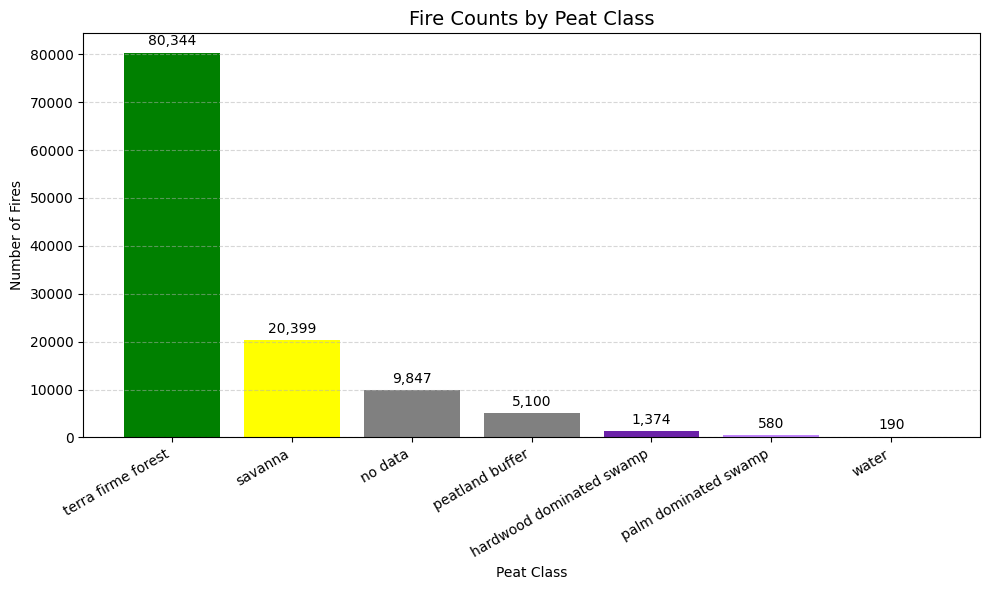

In [23]:
warnings.filterwarnings("ignore", message="Glyph 128293")
# --- Count fires by peat class (including NaN) ---
peat_counts = (
    fires_within_adm1["peat_class_name"]
    .value_counts(dropna=False)
    .rename_axis("Peat Class")
    .reset_index(name="Fire Count")
)

# Replace NaN with "No Data"
peat_counts["Peat Class"] = peat_counts["Peat Class"].fillna("No Data")

# --- Define color mapping ---
color_map = {
    "terra firme forest": "green",
    "savanna": "yellow",
    "no data": "grey",
    "palm dominated swamp": "#c084fc",   # light purple
    "hardwood dominated swamp": "#6b21a8",  # dark purple
    "water":"blue",
    "buffer":"red"
}

# --- Map colors (default grey for unknowns) ---
peat_counts["Color"] = peat_counts["Peat Class"].str.lower().map(color_map).fillna("grey")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    peat_counts["Peat Class"],
    peat_counts["Fire Count"],
    color=peat_counts["Color"]
)

# --- Add labels on bars ---
ax.bar_label(bars, labels=[f"{v:,}" for v in peat_counts["Fire Count"]],
             label_type="edge", padding=3, fontsize=10, color="black")

# --- Style ---
ax.set_title("Fire Counts by Peat Class", fontsize=14)
ax.set_xlabel("Peat Class")
ax.set_ylabel("Number of Fires")
plt.xticks(rotation=30, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [24]:
# Remove rows where peat_class_name is "No Data" or NaN
fires_within_adm1 = fires_within_adm1[
    fires_within_adm1["peat_class_name"].notna() & 
    (fires_within_adm1["peat_class_name"].str.lower() != "no data")
].copy()

print(f"Remaining records after filtering: {len(fires_within_adm1)}")
fires_within_adm1['peat_class_name'].value_counts()

Remaining records after filtering: 107987


peat_class_name
terra firme forest          80344
savanna                     20399
peatland buffer              5100
hardwood dominated swamp     1374
palm dominated swamp          580
water                         190
Name: count, dtype: int64

In [25]:
if isinstance(ADM1, (shapely.geometry.Polygon, shapely.geometry.MultiPolygon)):
    ADM1 = gpd.GeoDataFrame(geometry=[ADM1], crs=fires_within_adm1.crs)

# ------------------------------------------------------------------
# Join ALL attributes from join layer and prefix them
# ------------------------------------------------------------------
def spatial_join_all_prefix(base_gdf, join_gdf, prefix, predicate="intersects"):
    join_gdf = join_gdf.copy()

    # Drop common nuisance columns if present
    join_gdf.drop(columns=["Shape_Area", "Shape_Leng"], errors="ignore", inplace=True)

    joined = gpd.sjoin(base_gdf, join_gdf, how="left", predicate=predicate)

    join_cols = [c for c in join_gdf.columns if c != "geometry"]

    rename_dict = {c: f"{prefix}_{c}" for c in join_cols if c in joined.columns}
    joined.rename(columns=rename_dict, inplace=True)

    joined.drop(columns=["index_right"], errors="ignore", inplace=True)
    return joined

# ------------------------------------------------------------------
# Join ONLY specified columns (your existing behavior) – optional
# ------------------------------------------------------------------
def spatial_join_some_prefix(base_gdf, join_gdf, columns, prefix, predicate="intersects"):
    join_gdf = join_gdf.copy()

    # Case-insensitive matching for requested columns
    col_map = {c.lower(): c for c in join_gdf.columns}
    matched = [col_map[c.lower()] for c in columns if c.lower() in col_map]

    keep_cols = ["geometry"] + matched
    join_gdf = join_gdf[keep_cols].copy()

    join_gdf.drop(columns=["Shape_Area", "Shape_Leng"], errors="ignore", inplace=True)

    joined = gpd.sjoin(base_gdf, join_gdf, how="left", predicate=predicate)

    rename_dict = {c: f"{prefix}_{c}" for c in matched if c in joined.columns}
    joined.rename(columns=rename_dict, inplace=True)

    joined.drop(columns=["index_right"], errors="ignore", inplace=True)
    return joined

# ------------------------------------------------------------------
# Apply joins
# ------------------------------------------------------------------
fires_all_atts = spatial_join_all_prefix(fires_within_adm1, ADM1, "ADM")

# Others: keep only what you need (optional; change to spatial_join_all_prefix if desired)
fires_all_atts = spatial_join_some_prefix(fires_all_atts, PAs, ["NAME"], "PA")
fires_all_atts = spatial_join_some_prefix(fires_all_atts, CONC_COD, ["desc_type"], "for_conc_COD")
fires_all_atts = spatial_join_some_prefix(fires_all_atts, CONC_COG, ["ste_att_en"], "for_conc_COG")

# ------------------------------------------------------------------
# Indicator fields
# ------------------------------------------------------------------
fires_all_atts["PA"] = np.where(fires_all_atts.get("PA_NAME").notna(), 1, 0)
fires_all_atts["for_conc_COD"] = np.where(fires_all_atts.get("for_conc_COD_desc_type").notna(), 1, 0)
fires_all_atts["for_conc_COG"] = np.where(fires_all_atts.get("for_conc_COG_ste_att_en").notna(), 1, 0)

fires_all_atts.head(5)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,ADM_gaul1_code,ADM_gaul1_name,ADM_continent,ADM_disp_en,PA_NAME,for_conc_COD_desc_type,for_conc_COG_ste_att_en,PA,for_conc_COD,for_conc_COG
50569,3.23362,19.07410,NaN,0.71,0.75,2026-03-04,1259,NOAA20,VIIRS,n,...,1233,Sud-Ubangi,Africa,"Sud-Ubangi, Democratic Republic of the Congo",NaN,NaN,NaN,0,0,0
5036,1.70405,19.93627,NaN,0.39,0.36,2026-03-04,1210,NOAA21,VIIRS,n,...,1228,Mongala,Africa,"Mongala, Democratic Republic of the Congo",NaN,NaN,NaN,0,0,0
5059,2.15339,20.39053,NaN,0.40,0.37,2026-03-04,1210,NOAA21,VIIRS,n,...,1228,Mongala,Africa,"Mongala, Democratic Republic of the Congo",NaN,NaN,NaN,0,0,0
5064,2.18048,18.62919,NaN,0.38,0.36,2026-03-04,1210,NOAA21,VIIRS,n,...,1233,Sud-Ubangi,Africa,"Sud-Ubangi, Democratic Republic of the Congo",NaN,NaN,NaN,0,0,0
5069,2.20835,18.67378,NaN,0.38,0.36,2026-03-04,1210,NOAA21,VIIRS,n,...,1233,Sud-Ubangi,Africa,"Sud-Ubangi, Democratic Republic of the Congo",NaN,NaN,NaN,0,0,0


In [26]:
print("\n".join(fires_all_atts.columns))

latitude
longitude
brightness
scan
track
acq_date
acq_time
satellite
instrument
confidence
version
bright_t31
frp
daynight
bright_ti4
bright_ti5
geometry
confidence_num
peat_class_code
peat_class_name
ADM_iso3_code
ADM_map_code
ADM_gaul0_code
ADM_gaul0_name
ADM_gaul1_code
ADM_gaul1_name
ADM_continent
ADM_disp_en
PA_NAME
for_conc_COD_desc_type
for_conc_COG_ste_att_en
PA
for_conc_COD
for_conc_COG


#### 3. Evaluate and visualize

🔥 Fire detections by source:
  satellite  Fire Count
0      SNPP       37696
1    NOAA21       33733
2    NOAA20       33414
3     MODIS        3144


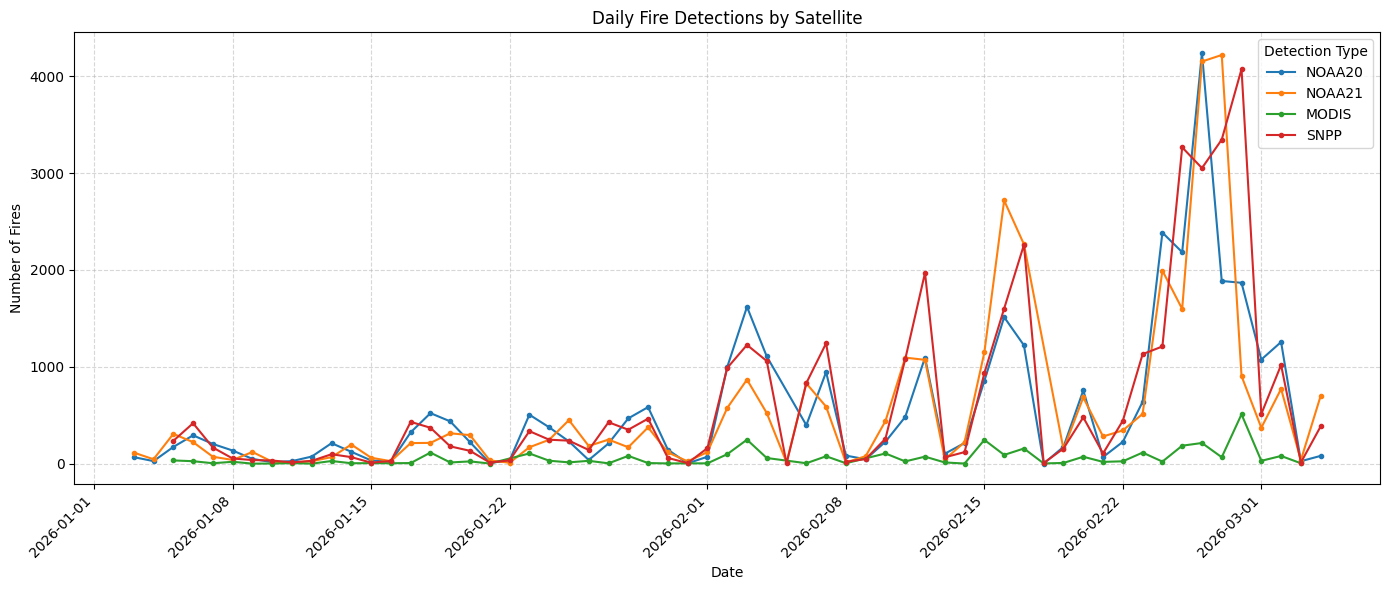

In [27]:
fire_counts = fires_all_atts["satellite"].value_counts().reset_index()
fire_counts.columns = ["satellite", "Fire Count"]

print("🔥 Fire detections by source:")
print(fire_counts)

fires_all_atts["acq_date"] = pd.to_datetime(fires_all_atts["acq_date"], errors="coerce")

daily_counts = fires_all_atts.groupby(["acq_date", "satellite"]).size().reset_index(name="Fire Count")

warnings.filterwarnings("ignore", message="Glyph .* missing from font")

plt.figure(figsize=(14, 6))
for src in daily_counts["satellite"].unique():
    data = daily_counts[daily_counts["satellite"] == src]
    plt.plot(data["acq_date"], data["Fire Count"], marker="o", markersize=3, label=src)

plt.title("Daily Fire Detections by Satellite")
plt.xlabel("Date")
plt.ylabel("Number of Fires")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Detection Type")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

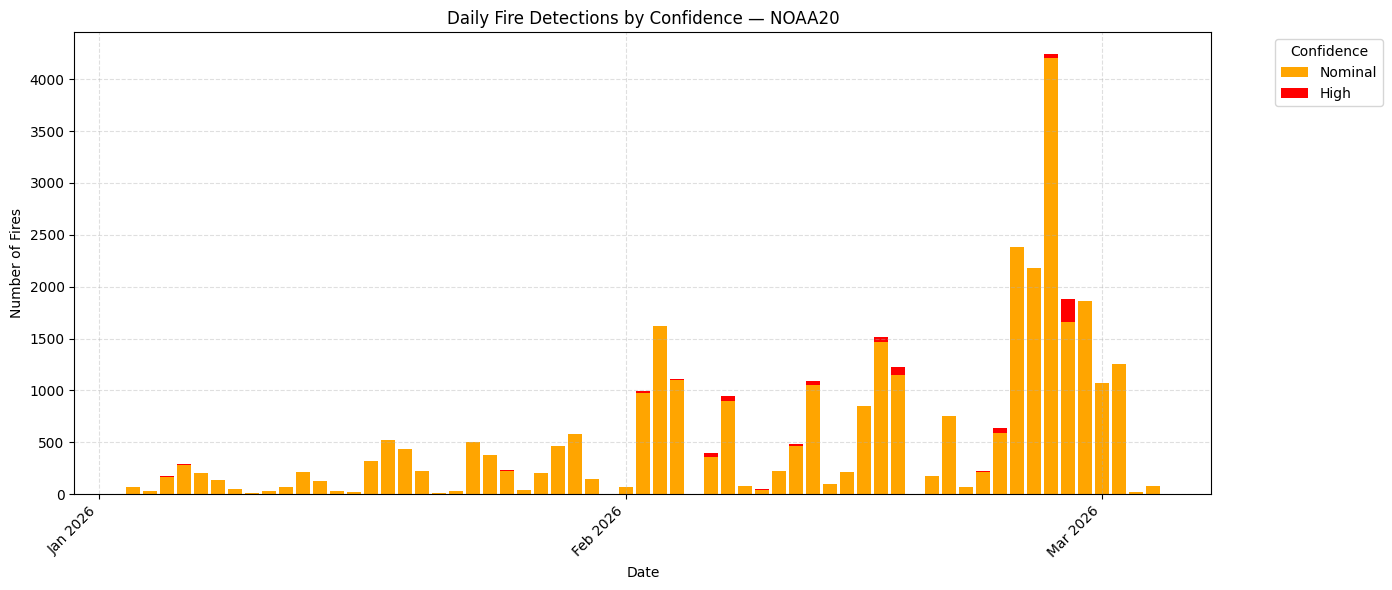

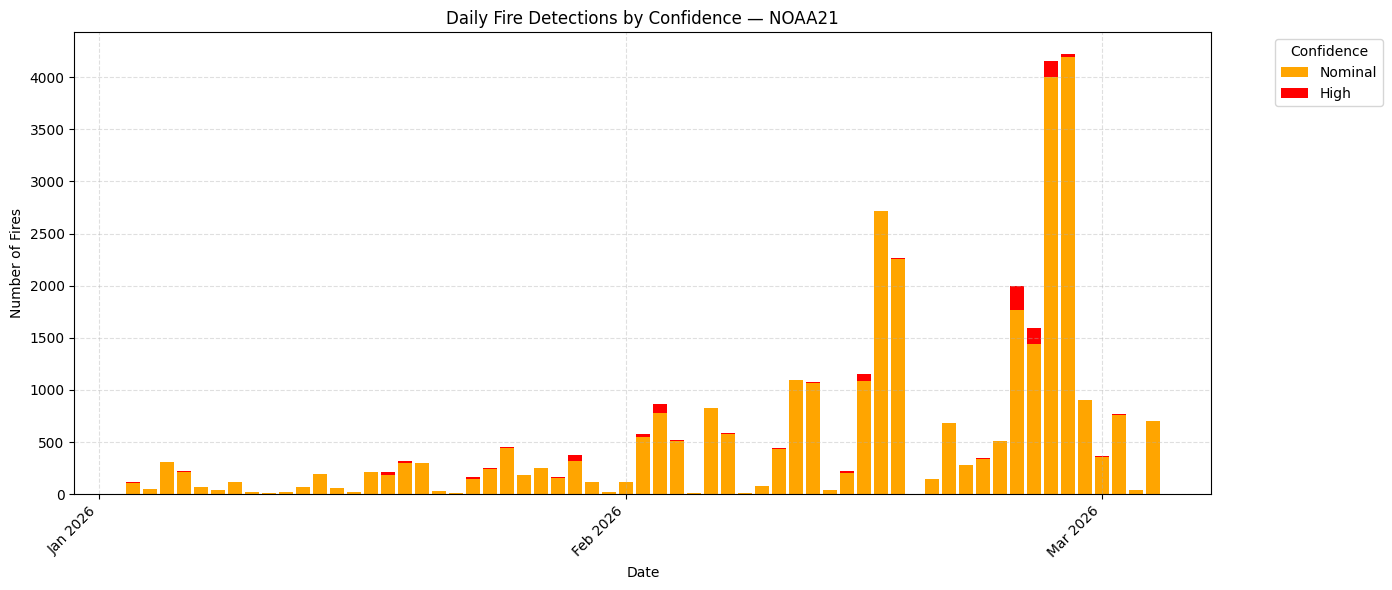

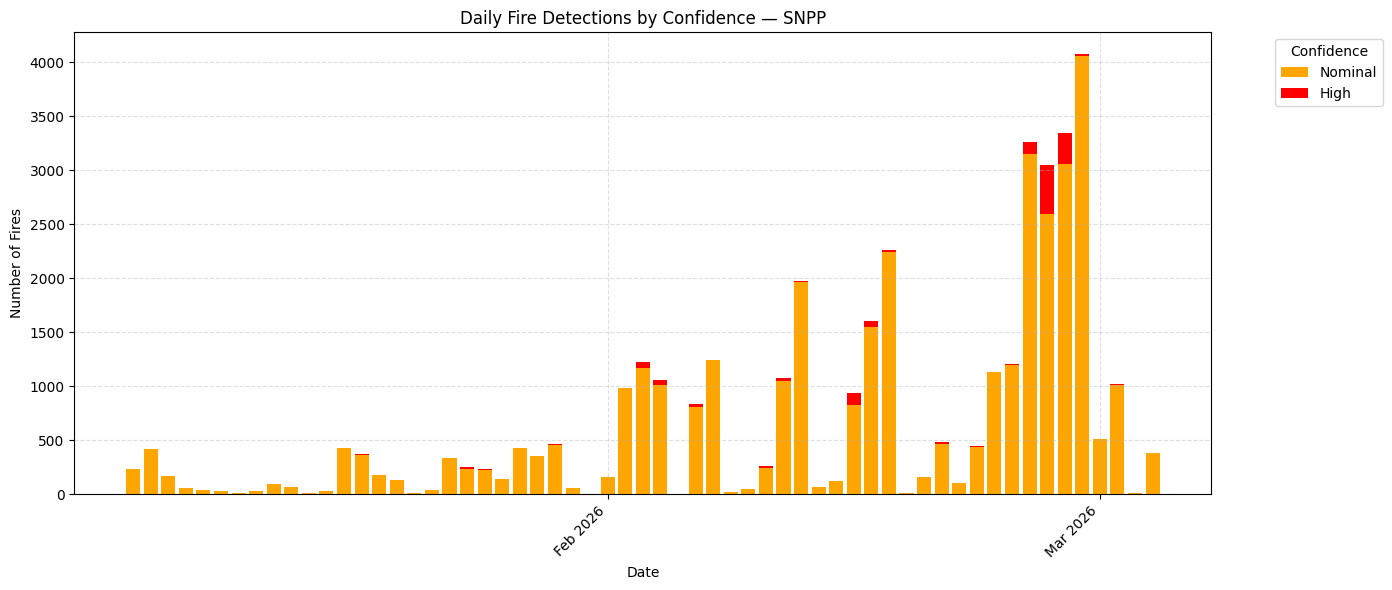

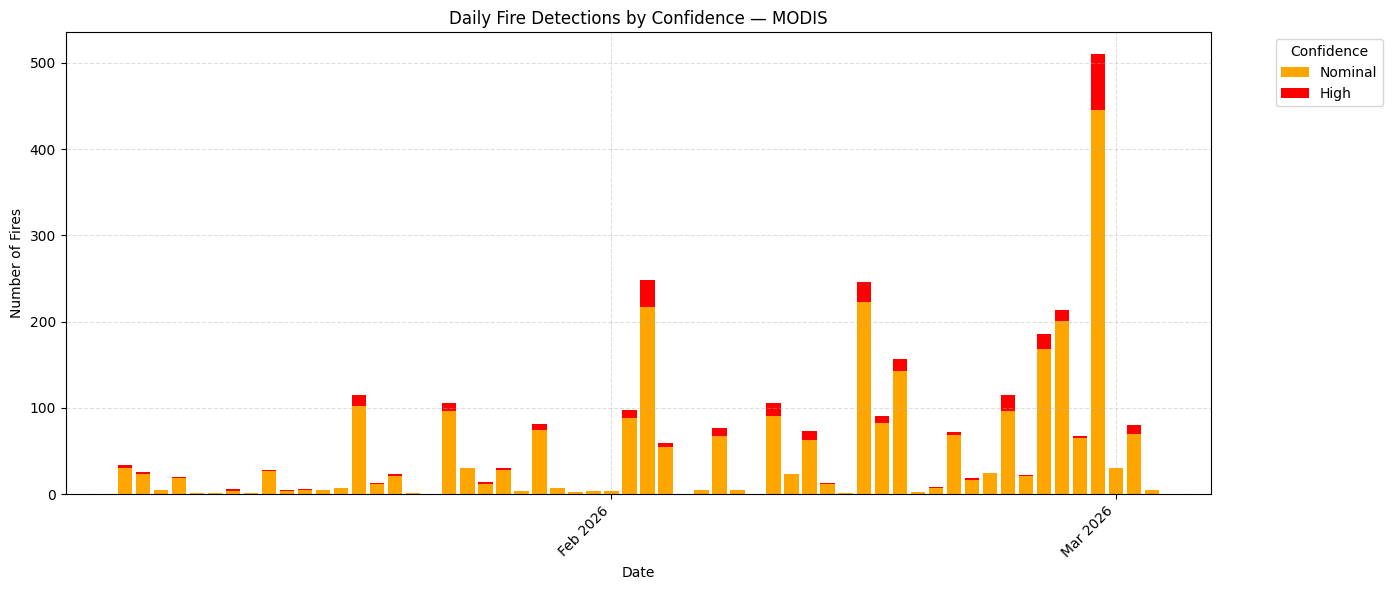

In [28]:
# -------------------------------------------------------
# Convert acquisition date
# -------------------------------------------------------
fires_all_atts["acq_date"] = pd.to_datetime(
    fires_all_atts["acq_date"], errors="coerce"
)

# -------------------------------------------------------
# Harmonize confidence values
# -------------------------------------------------------
fires_all_atts["confidence_num"] = pd.to_numeric(
    fires_all_atts["confidence"], errors="coerce"
)

# Numeric confidence (MODIS)
fires_all_atts["confidence_class"] = pd.cut(
    fires_all_atts["confidence_num"],
    bins=[-np.inf, 30, 80, np.inf],
    labels=["Low", "Nominal", "High"],
    right=False
)

# Replace VIIRS categorical confidence
fires_all_atts.loc[
    fires_all_atts["confidence"].astype(str).str.lower().isin(["l", "low"]),
    "confidence_class"
] = "Low"

fires_all_atts.loc[
    fires_all_atts["confidence"].astype(str).str.lower().isin(["n", "nominal"]),
    "confidence_class"
] = "Nominal"

fires_all_atts.loc[
    fires_all_atts["confidence"].astype(str).str.lower().isin(["h", "high"]),
    "confidence_class"
] = "High"

# -------------------------------------------------------
# Plot settings
# -------------------------------------------------------
confidence_order = ["Low", "Nominal", "High"]

colors = {
    "Low": "#fdbb84",
    "Nominal": "orange",
    "High": "red"
}

satellites = fires_all_atts["satellite"].dropna().unique()

warnings.filterwarnings("ignore", message="Glyph .* missing from font")

# -------------------------------------------------------
# Plot per satellite
# -------------------------------------------------------
for sat in satellites:

    sat_df = fires_all_atts[fires_all_atts["satellite"] == sat]

    # Count fires by date + confidence
    daily_conf_counts = (
        sat_df
        .groupby(["acq_date", "confidence_class"], observed=True)
        .size()
        .reset_index(name="Fire Count")
    )

    pivot_df = (
        daily_conf_counts
        .pivot(index="acq_date", columns="confidence_class", values="Fire Count")
        .fillna(0)
    )

    pivot_df = pivot_df.reindex(
        columns=[c for c in confidence_order if c in pivot_df.columns]
    )

    # ---------------------------------------------------
    # Plot stacked bars
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(14, 6))

    bottom = pd.Series(0, index=pivot_df.index)

    for conf in pivot_df.columns:
        ax.bar(
            pivot_df.index,
            pivot_df[conf],
            bottom=bottom,
            color=colors.get(conf, "gray"),
            label=conf
        )
        bottom += pivot_df[conf]

    # ---------------------------------------------------
    # Axis formatting
    # ---------------------------------------------------
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    plt.xticks(rotation=45, ha="right")

    plt.title(f"Daily Fire Detections by Confidence — {sat}")
    plt.xlabel("Date")
    plt.ylabel("Number of Fires")

    plt.legend(
        title="Confidence",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

Filtered fires: 7,054 out of 107,987 total


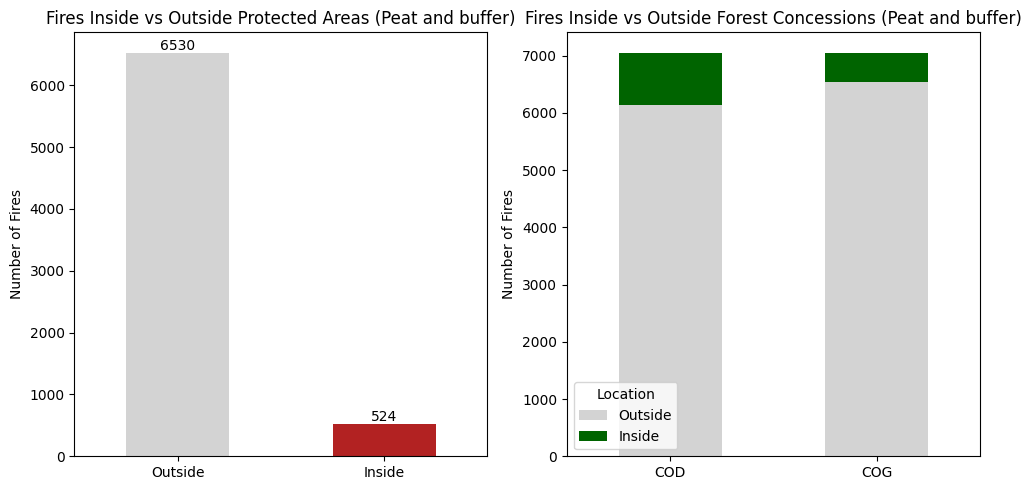


Protected Areas:
 PA
Outside    6530
Inside      524
Name: count, dtype: int64

Forest Concessions:
      Outside  Inside
COD     6135     919
COG     6547     507


In [29]:
# --- 🔍 Filter fires by peat class ---
fires_peat = fires_all_atts[fires_all_atts["peat_class_code"] > 3].copy()

print(f"Filtered fires: {len(fires_peat):,} out of {len(fires_all_atts):,} total")

# --- Count inside/outside for Protected Areas ---
pa_counts = fires_peat["PA"].value_counts().rename({0: "Outside", 1: "Inside"})

# --- Count inside/outside for Forest Concessions (COD & COG separately) ---
cod_counts = fires_peat["for_conc_COD"].value_counts().rename({0: "Outside", 1: "Inside"})
cog_counts = fires_peat["for_conc_COG"].value_counts().rename({0: "Outside", 1: "Inside"})

# --- Create figure with subplots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# --- Plot 1: Protected Areas ---
pa_counts.plot(
    kind="bar",
    ax=axes[0],
    color=["lightgrey", "firebrick"],
    rot=0
)
axes[0].set_title("Fires Inside vs Outside Protected Areas (Peat and buffer)")
axes[0].set_ylabel("Number of Fires")
axes[0].set_xlabel("")
axes[0].bar_label(axes[0].containers[0], label_type='edge')

# --- Plot 2: Forest Concessions (COD + COG) ---
df_conc = pd.DataFrame({
    "COD": cod_counts,
    "COG": cog_counts
}).T.fillna(0).astype(int)

df_conc.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=["lightgrey", "darkgreen"],
    rot=0
)
axes[1].set_title("Fires Inside vs Outside Forest Concessions (Peat and buffer)")
axes[1].set_ylabel("Number of Fires")
axes[1].legend(title="Location")

plt.tight_layout()
plt.show()

# --- Optional: print summary tables ---
print("\nProtected Areas:\n", pa_counts)
print("\nForest Concessions:\n", df_conc)

In [30]:
#visualize in a map
# --- Ensure latitude/longitude columns exist ---
if not {"latitude", "longitude"}.issubset(fires_all_atts.columns):
    fires_all_atts["latitude"] = fires_all_atts.geometry.y
    fires_all_atts["longitude"] = fires_all_atts.geometry.x

# --- Prepare heatmap data ---
heat_data = fires_all_atts[["latitude", "longitude"]].dropna().values.tolist()

# --- Create map ---
m = folium.Map(
    location=[fires_all_atts.latitude.mean(), fires_all_atts.longitude.mean()],
    zoom_start=6,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery"
)

# --- Custom blue → red gradient ---
custom_gradient = {
    0.0: "blue",
    0.25: "cyan",
    0.5: "lime",
    0.75: "yellow",
    1.0: "red"
}

# --- Add heatmap layer ---
HeatMap(
    heat_data,
    name="Fire Heatmap",
    radius=6,
    blur=10,
    min_opacity=0.4,
    gradient=custom_gradient
).add_to(m)

# --- Add ADM1 polygon layer (transparent fill, white borders) ---
if "ADM1" in locals() and ADM1 is not None:
    folium.GeoJson(
        ADM1,
        name="ADM1 Boundaries",
        style_function=lambda x: {
            "color": "white",
            "weight": 1,
            "fill": False
        }
    ).add_to(m)

# --- Add AOI layer (optional) ---
if "AOI" in locals() and AOI is not None:
    folium.GeoJson(
        AOI,
        name="AOI",
        style_function=lambda x: {"color": "blue", "weight": 2, "fill": False}
    ).add_to(m)

# --- Add legend ---
legend_html = """
<div style="
position: fixed;
bottom: 10px; left: 10px; width: 200px; height: 90px;
background-color: white; border:2px solid grey; z-index:9999; font-size:13px;
padding: 10px;">
<b>🔥 Fire Density</b><br>
<svg width="180" height="15">
  <defs>
    <linearGradient id="grad" x1="0%" y1="0%" x2="100%" y2="0%">
      <stop offset="0%" style="stop-color:blue;stop-opacity:1" />
      <stop offset="25%" style="stop-color:cyan;stop-opacity:1" />
      <stop offset="50%" style="stop-color:lime;stop-opacity:1" />
      <stop offset="75%" style="stop-color:yellow;stop-opacity:1" />
      <stop offset="100%" style="stop-color:red;stop-opacity:1" />
    </linearGradient>
  </defs>
  <rect width="180" height="15" fill="url(#grad)" />
</svg><br>
Low&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;High
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# --- Layer control ---
folium.LayerControl().add_to(m)

m

In [32]:
# filter the fires by country
fires_all_atts_filt = fires_all_atts[
    fires_all_atts["ADM_iso3_code"] == "COG"
].copy()
print("Number of fires in Congo:", len(fires_all_atts_filt))

Number of fires in Congo: 6047


#### 4. upload results to Google Drive

In [33]:
# authorize upload to Google Drive
cred_path = Path.home() / ".config/earthengine/credentials"
with open(cred_path, "r") as f:
    access_token = json.load(f).get("access_token")
drive = build('drive', 'v3', credentials=Credentials(token=access_token))

In [34]:
#export to csv
# Build the filename with the date appended
output_path = f"/home/sepal-user/Peatlands_Congo/fires_Congo_2026.csv"
# Export first to csv in SEPAL
fires_all_atts_filt.to_csv(output_path, index_label='ID')

In [35]:
#Ensure Peatlands folder exists
folder_name = "Congo_Peatlands"
folder_results = drive.files().list(
    q=f"name='{folder_name}' and mimeType='application/vnd.google-apps.folder' and trashed=false",
    fields="files(id, name)"
).execute()
folders = folder_results.get("files", [])

if not folders:
    print(f"⚠️ Folder '{folder_name}' not found. Creating it...")
    folder_metadata = {"name": folder_name, "mimeType": "application/vnd.google-apps.folder"}
    folder = drive.files().create(body=folder_metadata, fields="id").execute()
    folder_id = folder["id"]
    print(f"🆕 Created folder '{folder_name}' (ID: {folder_id})")
else:
    folder_id = folders[0]["id"]
    print(f"📁 Found folder '{folder_name}' (ID: {folder_id})")

📁 Found folder 'Congo_Peatlands' (ID: 14T1F67Oe_jorIKQk5hGVa-BvPcmJHoUg)


In [36]:
# give a name to the output
SHEET_NAME = "Congo_Fire_Monitoring_2026"

In [37]:
fires_all_atts_filt.to_csv(output_path, index_label="ID")

print(f"📁 CSV exported locally: {output_path}")

# -------------------------------------------------------
# Google Drive upload
# -------------------------------------------------------
VIIRS_file_metadata = {
    "name": SHEET_NAME.replace(".csv", ""),
    "mimeType": "application/vnd.google-apps.spreadsheet",
    "parents": [folder_id]
}

media = MediaFileUpload(output_path, mimetype="text/csv", resumable=True)

# -------------------------------------------------------
# Check if file already exists
# -------------------------------------------------------
existing = drive.files().list(
    q=f"name='{SHEET_NAME.replace('.csv','')}' and '{folder_id}' in parents and trashed=false",
    fields="files(id,name)"
).execute()

files = existing.get("files", [])

# -------------------------------------------------------
# Replace or upload
# -------------------------------------------------------
if files:
    file_id = files[0]["id"]
    print(f"♻️ Replacing existing Google Sheet '{SHEET_NAME}'...")
    
    updated = drive.files().update(
        fileId=file_id,
        media_body=media
    ).execute()
    
    file_id = updated["id"]

else:
    uploaded = drive.files().create(
        body=VIIRS_file_metadata,
        media_body=media,
        fields="id"
    ).execute()
    
    file_id = uploaded["id"]

print(f"✅ '{SHEET_NAME}' uploaded to Google Drive folder '{folder_name}'")

# -------------------------------------------------------
# Display large clickable link
# -------------------------------------------------------
sheet_url = f"https://docs.google.com/spreadsheets/d/{file_id}/edit"

display(HTML(f"""
<div style="margin-top:20px;">
<b>Open Fire Data in Google</b><br>
<a href="{sheet_url}" target="_blank"
style="font-size:22px;font-weight:bold;color:#1a73e8;">
{sheet_url}
</a>
</div>
"""))

📁 CSV exported locally: /home/sepal-user/Peatlands_Congo/fires_Congo_2026.csv
✅ 'Congo_Fire_Monitoring_2026' uploaded to Google Drive folder 'Congo_Peatlands'


#### 5. export fires in peatlands to geoJSON for Ground

In [ ]:
# --- Filter fires in peat classes 4 or 5 ---
fires_peat = fires_all_atts[
    fires_all_atts["peat_class_code"].isin([4, 5, 6])
].copy()

print(f"✅ Selected {len(fires_peat):,} fire records in peat classes 4 & 5 & 6")

# --- Replace peat_class_code with peat_class_name ---
if "peat_class_name" in fires_all_atts.columns:
    fires_peat.drop(columns=["peat_class_code"], inplace=True, errors="ignore")
else:
    print("⚠️ 'peat_class_name' column not found — check dataset.")

# --- Add 'name' property using acquisition date ---
fires_peat["name"] = fires_peat["acq_date"].astype(str).apply(
    lambda d: f"Fire_{d[:10]}" if pd.notna(d) and len(d) >= 10 else "Fire_Unknown"
)

# --- Create dated filenames ---
today_str = datetime.today().strftime("%Y%m%d")

# --- Split and export by ADM0 ---
for adm0_code in ["COD", "COG"]:
    subset = fires_peat[fires_peat["ADM_iso3_code"] == adm0_code].copy()
    if subset.empty:
        print(f"⚠️ No records found for {adm0_code}")
        continue

    output_path = f"fires_peatland_{adm0_code}_{today_str}.geojson"
    subset.to_file(output_path, driver="GeoJSON")
    print(f"💾 Exported {len(subset):,} fires for {adm0_code} → {output_path}")